# 🔍 LGD Results Debugging & Diagnostic Analysis

This notebook provides comprehensive debugging and analysis to understand why LGD (Loss Given Default) prediction results may be poor compared to PD (Probability of Default).

## Key Investigation Areas:
1. **Data Quality**: Target distribution, outliers, missing values
2. **Prediction Analysis**: Raw vs clipped predictions, distribution mismatch
3. **Method Comparison**: Which methods work, which fail, and why
4. **Feature Analysis**: Are features predictive for LGD?
5. **Preprocessing Impact**: Normalization, encoding effects
6. **Statistical Diagnostics**: Residuals, heteroscedasticity, correlations
7. **Comparison with PD**: Why PD works but LGD doesn't

---

## 1. Setup & Imports

In [1]:
import pickle
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    median_absolute_error, max_error, explained_variance_score
)
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✅ Imports successful")

✅ Imports successful


## 2. Configuration

**⚠️ IMPORTANT**: Adjust these paths to match your project structure!

In [2]:
# =============================================================================
# CONFIGURATION - ADJUST THESE PATHS
# =============================================================================

# Project root (notebook is in notebooks/ folder)
PROJECT_ROOT = Path(".").resolve().parent
EXPERIMENT = "experiment1"  # Change this to your experiment name

# Paths
RESULTS_DIR = PROJECT_ROOT / "results" / EXPERIMENT
LGD_RESULTS_DIR = RESULTS_DIR / "lgd"
PD_RESULTS_DIR = RESULTS_DIR / "pd"
DATA_DIR = PROJECT_ROOT / "data" / "processed"

print("=" * 80)
print("LGD DEBUGGING NOTEBOOK - CONFIGURATION")
print("=" * 80)
print(f"Project root:     {PROJECT_ROOT}")
print(f"Experiment:       {EXPERIMENT}")
print(f"Results dir:      {RESULTS_DIR}")
print(f"LGD results dir:  {LGD_RESULTS_DIR}")
print(f"PD results dir:   {PD_RESULTS_DIR}")
print(f"Data dir:         {DATA_DIR}")
print()
print(f"LGD dir exists:   {LGD_RESULTS_DIR.exists()}")
print(f"PD dir exists:    {PD_RESULTS_DIR.exists()}")
print(f"Data dir exists:  {DATA_DIR.exists()}")

# List available files
if LGD_RESULTS_DIR.exists():
    lgd_files = list(LGD_RESULTS_DIR.glob("*.pkl"))
    print(f"\nLGD datasets available: {len(lgd_files)}")
    for f in lgd_files[:5]:
        print(f"  - {f.name}")
    if len(lgd_files) > 5:
        print(f"  ... and {len(lgd_files) - 5} more")
else:
    print("\n⚠️ LGD results directory not found!")

LGD DEBUGGING NOTEBOOK - CONFIGURATION
Project root:     C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit
Experiment:       experiment1
Results dir:      C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1
LGD results dir:  C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1\lgd
PD results dir:   C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1\pd
Data dir:         C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\data\processed

LGD dir exists:   True
PD dir exists:    True
Data dir exists:  True

LGD datasets available: 5
  - 0001.heloc.pkl
  - 0002.loss2.pkl
  - 0003.axa.pkl
  - 0004.base_model.pkl
  - 0005.base_modelisation.pkl


## 3. Helper Functions

In [3]:
# =============================================================================
# HELPER FUNCTIONS
# =============================================================================

ALGORITHM_DISPLAY_NAMES = {
    'tabpfn': 'TabPFN', 'tabpfn_v2': 'TabPFN-v2', 'xgboost': 'XGBoost',
    'lightgbm': 'LightGBM', 'catboost': 'CatBoost', 'RandomForest': 'RForest',
    'LinearRegression': 'LinReg', 'knn': 'KNN', 'svm': 'SVM',
    'mlp': 'MLP', 'tabnet': 'TabNet', 'resnet': 'ResNet',
    'LogReg': 'LogReg', 'NaiveBayes': 'NaiveBayes', 'dummy': 'Dummy',
}

def get_display_name(name):
    """Get human-readable method name."""
    return ALGORITHM_DISPLAY_NAMES.get(name, name)


def load_pickle(path):
    """Load pickle file."""
    with open(path, 'rb') as f:
        return pickle.load(f)


def list_datasets(results_dir):
    """List available datasets."""
    if not results_dir.exists():
        return []
    return sorted([f.stem for f in results_dir.glob("*.pkl") if "_metadata" not in f.stem])


def calculate_metrics(y_true, y_pred):
    """Calculate comprehensive regression metrics."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    
    metrics = {}
    
    try:
        metrics['R2'] = float(r2_score(y_true, y_pred))
    except:
        metrics['R2'] = np.nan
    
    metrics['MSE'] = float(mean_squared_error(y_true, y_pred))
    metrics['RMSE'] = float(np.sqrt(metrics['MSE']))
    metrics['MAE'] = float(mean_absolute_error(y_true, y_pred))
    metrics['MedAE'] = float(median_absolute_error(y_true, y_pred))
    
    # Correlation
    if np.std(y_pred) > 1e-10 and np.std(y_true) > 1e-10:
        metrics['Pearson'] = float(np.corrcoef(y_true, y_pred)[0, 1])
        metrics['Spearman'], _ = scipy_stats.spearmanr(y_true, y_pred)
    else:
        metrics['Pearson'] = np.nan
        metrics['Spearman'] = np.nan
    
    return metrics


def print_section(title):
    """Print formatted section header."""
    print(f"\n{'='*80}")
    print(f"  {title}")
    print(f"{'='*80}\n")


print("✅ Helper functions defined")

✅ Helper functions defined


## 4. Load and Inspect Data Structure

Understanding the exact structure of your results pickle files is critical for debugging.

In [4]:
print_section("4. DATA STRUCTURE INSPECTION")

lgd_datasets = list_datasets(LGD_RESULTS_DIR)
print(f"Available LGD datasets: {lgd_datasets}")

if lgd_datasets:
    # Load first dataset to inspect structure
    sample_dataset = lgd_datasets[0]
    sample_path = LGD_RESULTS_DIR / f"{sample_dataset}.pkl"
    sample_data = load_pickle(sample_path)
    
    print(f"\n📂 Inspecting: {sample_dataset}")
    print(f"   Type: {type(sample_data)}")
    
    if isinstance(sample_data, dict):
        print(f"   Top-level keys: {list(sample_data.keys())}")
        
        # Inspect structure
        for hpo_mode in sample_data.keys():
            print(f"\n   [{hpo_mode}]")
            methods = list(sample_data[hpo_mode].keys())
            print(f"      Methods ({len(methods)}): {methods}")
            
            if methods:
                first_method = methods[0]
                folds = list(sample_data[hpo_mode][first_method].keys())
                print(f"      Folds: {folds}")
                
                if folds:
                    first_fold = folds[0]
                    fold_data = sample_data[hpo_mode][first_method][first_fold]
                    print(f"      Fold data keys: {list(fold_data.keys())}")
                    
                    # Show shapes
                    print(f"\n      📊 Data shapes for {first_method}, fold {first_fold}:")
                    for key, value in fold_data.items():
                        if isinstance(value, np.ndarray):
                            print(f"         {key}: shape={value.shape}, dtype={value.dtype}")
                        elif isinstance(value, dict):
                            print(f"         {key}: dict with {len(value)} items")
                        else:
                            print(f"         {key}: {type(value).__name__}")
else:
    print("⚠️ No LGD datasets found!")


  4. DATA STRUCTURE INSPECTION

Available LGD datasets: ['0001.heloc', '0002.loss2', '0003.axa', '0004.base_model', '0005.base_modelisation']

📂 Inspecting: 0001.heloc
   Type: <class 'dict'>
   Top-level keys: ['NO_HPO', 'HPO']

   [NO_HPO]
      Methods (10): ['catboost', 'knn', 'lightgbm', 'LinearRegression', 'RandomForest', 'xgboost', 'svm', 'mlp', 'tabnet', 'tabpfn_v2']
      Folds: [1, 2, 3, 4, 5]
      Fold data keys: ['y_true', 'y_prob', 'y_pred', 'y_pred_raw', 'metrics', 'n_clipped_below', 'n_clipped_above', 'train_time', 'info', 'method', 'dataset', 'task', 'fold_id', 'used_hpo']

      📊 Data shapes for catboost, fold 1:
         y_true: shape=(13580,), dtype=float64
         y_prob: NoneType
         y_pred: shape=(13580,), dtype=float64
         y_pred_raw: shape=(13580,), dtype=float64
         metrics: dict with 10 items
         n_clipped_below: int
         n_clipped_above: int
         train_time: float
         info: dict with 3 items
         method: str
         d

## 5. Target Distribution Analysis

LGD is inherently difficult because the target distribution is often:
- Bimodal (many 0s and 1s)
- Skewed
- Bounded [0, 1]

Let's analyze the actual distributions.

In [5]:
print_section("5. TARGET (y_true) DISTRIBUTION ANALYSIS")

def analyze_target_distribution(results_dir, datasets):
    """Analyze y_true distributions across all datasets."""
    
    all_targets = {}
    
    for dataset in datasets:
        data = load_pickle(results_dir / f"{dataset}.pkl")
        
        # Get y_true from first available method
        for hpo_mode in ['NO_HPO', 'HPO']:
            if hpo_mode not in data:
                continue
            for method in data[hpo_mode]:
                y_true_all = []
                for fold_id, fold_data in data[hpo_mode][method].items():
                    if 'y_true' in fold_data:
                        y_true_all.extend(np.asarray(fold_data['y_true']).ravel())
                
                if y_true_all:
                    all_targets[dataset] = np.array(y_true_all)
                    break
            if dataset in all_targets:
                break
    
    return all_targets


if lgd_datasets:
    lgd_targets = analyze_target_distribution(LGD_RESULTS_DIR, lgd_datasets)
    
    # Create summary table
    target_stats = []
    for dataset, y_true in lgd_targets.items():
        target_stats.append({
            'Dataset': dataset,
            'N': len(y_true),
            'Min': y_true.min(),
            'Max': y_true.max(),
            'Mean': y_true.mean(),
            'Std': y_true.std(),
            'Median': np.median(y_true),
            'Skewness': scipy_stats.skew(y_true),
            'Kurtosis': scipy_stats.kurtosis(y_true),
            'Zeros': (y_true == 0).sum(),
            'Ones': (y_true == 1).sum(),
            'Pct_0': 100 * (y_true == 0).sum() / len(y_true),
            'Pct_1': 100 * (y_true == 1).sum() / len(y_true),
            'Unique': len(np.unique(y_true)),
        })
    
    target_df = pd.DataFrame(target_stats)
    print("📊 TARGET DISTRIBUTION SUMMARY:")
    print("-" * 100)
    display(target_df.round(4))
else:
    print("⚠️ No LGD datasets to analyze")


  5. TARGET (y_true) DISTRIBUTION ANALYSIS

📊 TARGET DISTRIBUTION SUMMARY:
----------------------------------------------------------------------------------------------------


,Dataset,N,Min,Max,Mean,Std,Median,Skewness,Kurtosis,Zeros,Ones,Pct_0,Pct_1,Unique
0,0001.heloc,67898,-0.0341,2.9898,0.6794,0.4316,0.9996,-0.7614,-1.0740,16724,29422,24.6311,43.3326,1856
1,0002.loss2,4638,0.0000,1.0000,0.3920,0.2713,0.3515,0.5558,-0.5254,168,172,3.6223,3.7085,4284
2,0003.axa,2545,0.0000,1.0000,0.2281,0.3290,0.0321,1.3089,0.2765,0,0,0.0000,0.0000,1675
3,0004.base_model,762,0.0000,1.0000,0.3234,0.3774,0.1032,0.8270,-0.9798,80,91,10.4987,11.9423,483
4,0005.base_modelisation,594,0.0000,1.0000,0.3301,0.4094,0.0435,0.7643,-1.2223,69,95,11.6162,15.9933,383


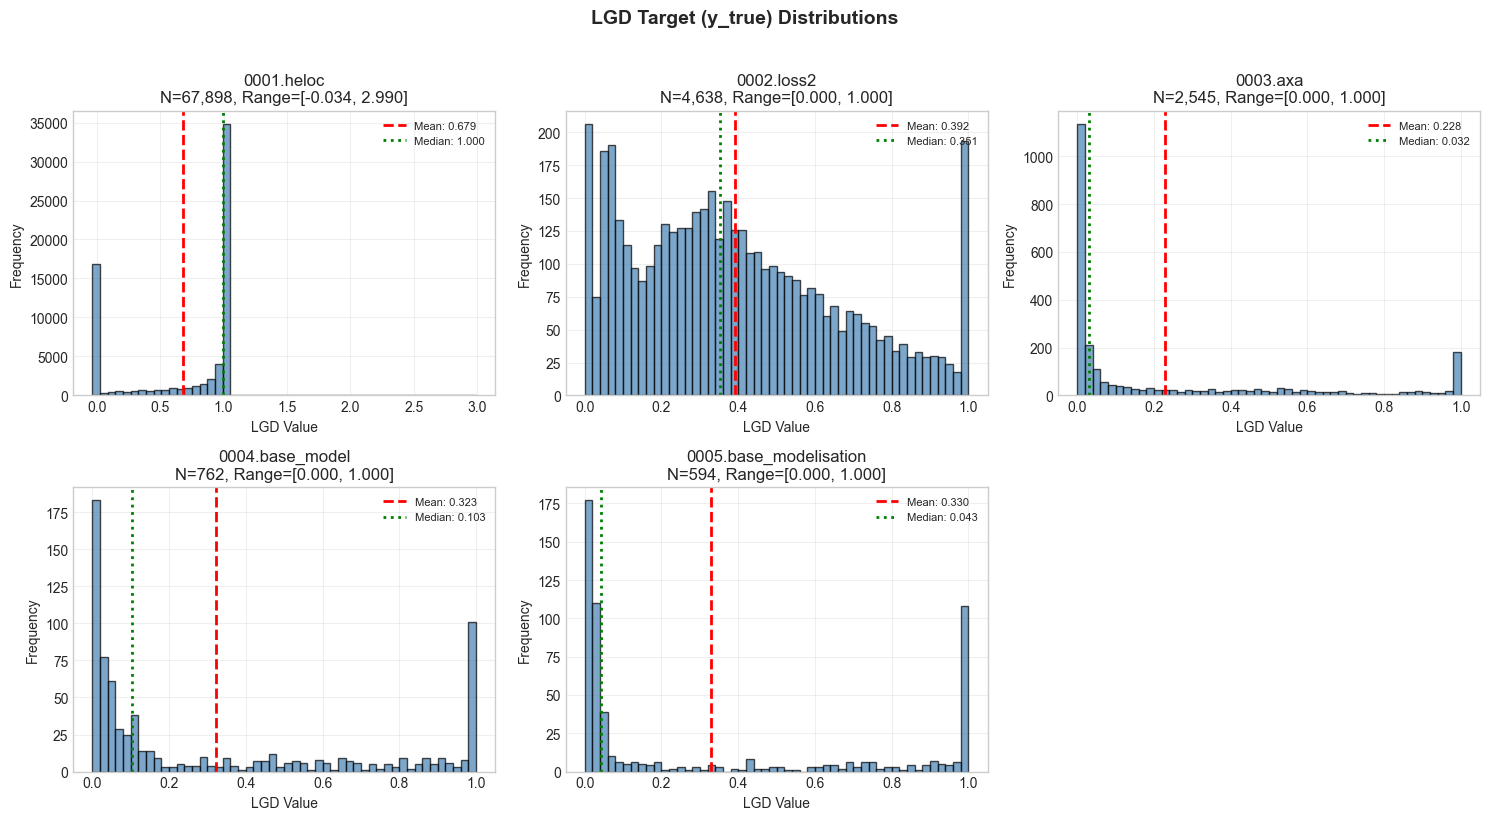


⚠️ POTENTIAL TARGET DISTRIBUTION ISSUES:
--------------------------------------------------
   0001.heloc: High one rate: 43.3%
   0003.axa: High skewness: 1.31


In [6]:
# Visualize target distributions
if lgd_datasets and 'lgd_targets' in dir() and lgd_targets:
    n_datasets = len(lgd_targets)
    n_cols = min(3, n_datasets)
    n_rows = (n_datasets + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = np.atleast_2d(axes).flatten()
    
    for idx, (dataset, y_true) in enumerate(lgd_targets.items()):
        ax = axes[idx]
        
        ax.hist(y_true, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
        ax.axvline(y_true.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {y_true.mean():.3f}')
        ax.axvline(np.median(y_true), color='green', linestyle=':', linewidth=2, label=f'Median: {np.median(y_true):.3f}')
        
        ax.set_xlabel('LGD Value')
        ax.set_ylabel('Frequency')
        ax.set_title(f'{dataset}\nN={len(y_true):,}, Range=[{y_true.min():.3f}, {y_true.max():.3f}]')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(lgd_targets), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('LGD Target (y_true) Distributions', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # KEY DIAGNOSTIC: Check for problematic distributions
    print("\n⚠️ POTENTIAL TARGET DISTRIBUTION ISSUES:")
    print("-" * 50)
    issues_found = False
    for _, row in target_df.iterrows():
        issues = []
        if row['Pct_0'] > 30:
            issues.append(f"High zero rate: {row['Pct_0']:.1f}%")
        if row['Pct_1'] > 30:
            issues.append(f"High one rate: {row['Pct_1']:.1f}%")
        if abs(row['Skewness']) > 1:
            issues.append(f"High skewness: {row['Skewness']:.2f}")
        if row['Unique'] < 10:
            issues.append(f"Low unique values: {row['Unique']}")
        if row['Max'] - row['Min'] < 0.1:
            issues.append(f"Narrow range: {row['Max'] - row['Min']:.3f}")
        
        if issues:
            issues_found = True
            print(f"   {row['Dataset']}: {', '.join(issues)}")
    
    if not issues_found:
        print("   ✅ No major target distribution issues detected")

## 6. Prediction vs Target Analysis

Compare raw predictions (before clipping) with actual targets. This reveals:
- If models are predicting outside [0,1] range
- Distribution mismatch between predictions and targets
- Whether clipping is helping or hurting

In [7]:
print_section("6. PREDICTION VS TARGET ANALYSIS")

def analyze_predictions(results_dir, dataset, hpo_mode='NO_HPO'):
    """Detailed analysis of predictions for a dataset."""
    
    data = load_pickle(results_dir / f"{dataset}.pkl")
    
    if hpo_mode not in data:
        print(f"HPO mode '{hpo_mode}' not found")
        return None
    
    analysis = {}
    
    for method in data[hpo_mode]:
        all_y_true = []
        all_y_pred_raw = []
        all_y_pred = []
        n_clipped_below_total = 0
        n_clipped_above_total = 0
        
        for fold_id, fold_data in data[hpo_mode][method].items():
            y_true = np.asarray(fold_data['y_true']).ravel()
            all_y_true.extend(y_true)
            
            if 'y_pred_raw' in fold_data:
                y_pred_raw = np.asarray(fold_data['y_pred_raw']).ravel()
                all_y_pred_raw.extend(y_pred_raw)
            
            if 'y_pred' in fold_data:
                y_pred = np.asarray(fold_data['y_pred']).ravel()
                all_y_pred.extend(y_pred)
            
            if 'n_clipped_below' in fold_data:
                n_clipped_below_total += fold_data['n_clipped_below']
            if 'n_clipped_above' in fold_data:
                n_clipped_above_total += fold_data['n_clipped_above']
        
        all_y_true = np.array(all_y_true)
        all_y_pred_raw = np.array(all_y_pred_raw) if all_y_pred_raw else None
        all_y_pred = np.array(all_y_pred) if all_y_pred else None
        
        analysis[method] = {
            'y_true': all_y_true,
            'y_pred_raw': all_y_pred_raw,
            'y_pred': all_y_pred,
            'n_clipped_below': n_clipped_below_total,
            'n_clipped_above': n_clipped_above_total,
        }
    
    return analysis


if lgd_datasets:
    dataset = lgd_datasets[0]
    print(f"📊 Analyzing predictions for: {dataset}")
    
    pred_analysis = analyze_predictions(LGD_RESULTS_DIR, dataset, 'NO_HPO')
    
    if pred_analysis:
        # Summary table
        summary_data = []
        for method, data in pred_analysis.items():
            y_true = data['y_true']
            y_pred_raw = data['y_pred_raw']
            y_pred = data['y_pred']
            
            row = {
                'Method': get_display_name(method),
                'N': len(y_true),
            }
            
            # y_true stats
            row['y_true_min'] = y_true.min()
            row['y_true_max'] = y_true.max()
            row['y_true_mean'] = y_true.mean()
            row['y_true_std'] = y_true.std()
            
            # y_pred_raw stats
            if y_pred_raw is not None:
                row['y_pred_raw_min'] = y_pred_raw.min()
                row['y_pred_raw_max'] = y_pred_raw.max()
                row['y_pred_raw_mean'] = y_pred_raw.mean()
                row['y_pred_raw_std'] = y_pred_raw.std()
                row['clipped_below'] = data['n_clipped_below']
                row['clipped_above'] = data['n_clipped_above']
                row['clipped_pct'] = 100 * (data['n_clipped_below'] + data['n_clipped_above']) / len(y_true)
            
            # Metrics (using clipped predictions)
            if y_pred is not None:
                metrics = calculate_metrics(y_true, y_pred)
                row.update(metrics)
            
            summary_data.append(row)
        
        summary_df = pd.DataFrame(summary_data)
        
        print("\n📊 PREDICTION STATISTICS:")
        print("-" * 120)
        cols_to_show = ['Method', 'N', 'y_true_mean', 'y_true_std', 'y_pred_raw_mean', 'y_pred_raw_std', 
                        'clipped_pct', 'R2', 'RMSE', 'Pearson']
        cols_available = [c for c in cols_to_show if c in summary_df.columns]
        display(summary_df[cols_available].round(4))


  6. PREDICTION VS TARGET ANALYSIS

📊 Analyzing predictions for: 0001.heloc

📊 PREDICTION STATISTICS:
------------------------------------------------------------------------------------------------------------------------


,Method,N,y_true_mean,y_true_std,y_pred_raw_mean,y_pred_raw_std,clipped_pct,R2,RMSE,Pearson
0,CatBoost,67898,0.6794,0.4316,0.0015,0.7337,31.8345,-0.3942,0.5096,0.6495
1,KNN,67898,0.6794,0.4316,0.0099,0.8715,35.1174,-0.0496,0.4422,0.6669
2,LightGBM,67898,0.6794,0.4316,0.0027,0.8639,33.7300,0.1361,0.4012,0.8106
3,LinReg,67898,0.6794,0.4316,-0.0001,0.5984,27.2497,-0.9775,0.6069,0.4388
4,RForest,67898,0.6794,0.4316,0.0067,0.7292,30.9405,-0.3222,0.4963,0.7055
5,XGBoost,67898,0.6794,0.4316,0.0034,0.9259,35.9466,0.2503,0.3737,0.8138
6,SVM,67898,0.6794,0.4316,0.3699,0.7730,15.3318,0.1859,0.3894,0.5020
7,MLP,67898,0.6794,0.4316,0.0465,0.7009,29.4088,-0.4544,0.5205,0.5552
8,TabNet,67898,0.6794,0.4316,-0.0025,0.6525,33.3986,-0.7840,0.5765,0.4978
9,TabPFN-v2,50000,0.6165,0.4545,0.0875,0.6837,22.2320,0.0026,0.4539,0.6607


In [8]:
# KEY DIAGNOSTIC: Check prediction issues
if 'summary_df' in dir() and summary_df is not None:
    print("\n⚠️ PREDICTION ISSUES DETECTED:")
    print("-" * 60)
    issues_found = False
    
    for _, row in summary_df.iterrows():
        issues = []
        
        if 'clipped_pct' in row and not pd.isna(row['clipped_pct']) and row['clipped_pct'] > 5:
            issues.append(f"High clipping: {row['clipped_pct']:.1f}%")
        
        if 'y_pred_raw_min' in row and not pd.isna(row['y_pred_raw_min']):
            if row['y_pred_raw_min'] < -0.5:
                issues.append(f"Predictions very negative: {row['y_pred_raw_min']:.2f}")
            if row['y_pred_raw_max'] > 1.5:
                issues.append(f"Predictions exceed 1.5: {row['y_pred_raw_max']:.2f}")
        
        if 'R2' in row and not pd.isna(row['R2']) and row['R2'] < 0:
            issues.append(f"Negative R²: {row['R2']:.4f}")
        
        if 'y_pred_raw_std' in row and 'y_true_std' in row:
            if not pd.isna(row['y_pred_raw_std']) and not pd.isna(row['y_true_std']):
                std_ratio = row['y_pred_raw_std'] / (row['y_true_std'] + 1e-10)
                if std_ratio < 0.3:
                    issues.append(f"Low variance predictions (std ratio: {std_ratio:.2f})")
                if std_ratio > 3:
                    issues.append(f"High variance predictions (std ratio: {std_ratio:.2f})")
        
        if issues:
            issues_found = True
            print(f"   {row['Method']}: {', '.join(issues)}")
    
    if not issues_found:
        print("   ✅ No major prediction issues detected")


⚠️ PREDICTION ISSUES DETECTED:
------------------------------------------------------------
   CatBoost: High clipping: 31.8%, Predictions very negative: -2.29, Predictions exceed 1.5: 3.50, Negative R²: -0.3942
   KNN: High clipping: 35.1%, Predictions very negative: -1.63, Predictions exceed 1.5: 5.36, Negative R²: -0.0496
   LightGBM: High clipping: 33.7%, Predictions very negative: -2.72, Predictions exceed 1.5: 4.89
   LinReg: High clipping: 27.2%, Predictions very negative: -2.68, Predictions exceed 1.5: 3.66, Negative R²: -0.9775
   RForest: High clipping: 30.9%, Predictions very negative: -1.58, Predictions exceed 1.5: 4.79, Negative R²: -0.3222
   XGBoost: High clipping: 35.9%, Predictions very negative: -2.95, Predictions exceed 1.5: 5.41
   SVM: High clipping: 15.3%, Predictions very negative: -1.61
   MLP: High clipping: 29.4%, Predictions very negative: -2.63, Predictions exceed 1.5: 1.65, Negative R²: -0.4544
   TabNet: High clipping: 33.4%, Predictions very negative: -3

## 7. Method-by-Method Deep Dive Visualizations

For each method, create diagnostic plots:
1. Scatter: Predicted vs Actual
2. Residuals vs Actual (check heteroscedasticity)
3. Residual distribution (check normality)
4. Distribution comparison (predictions vs targets)


  7. METHOD-BY-METHOD VISUALIZATION

Creating diagnostic plots for: 0002.loss2


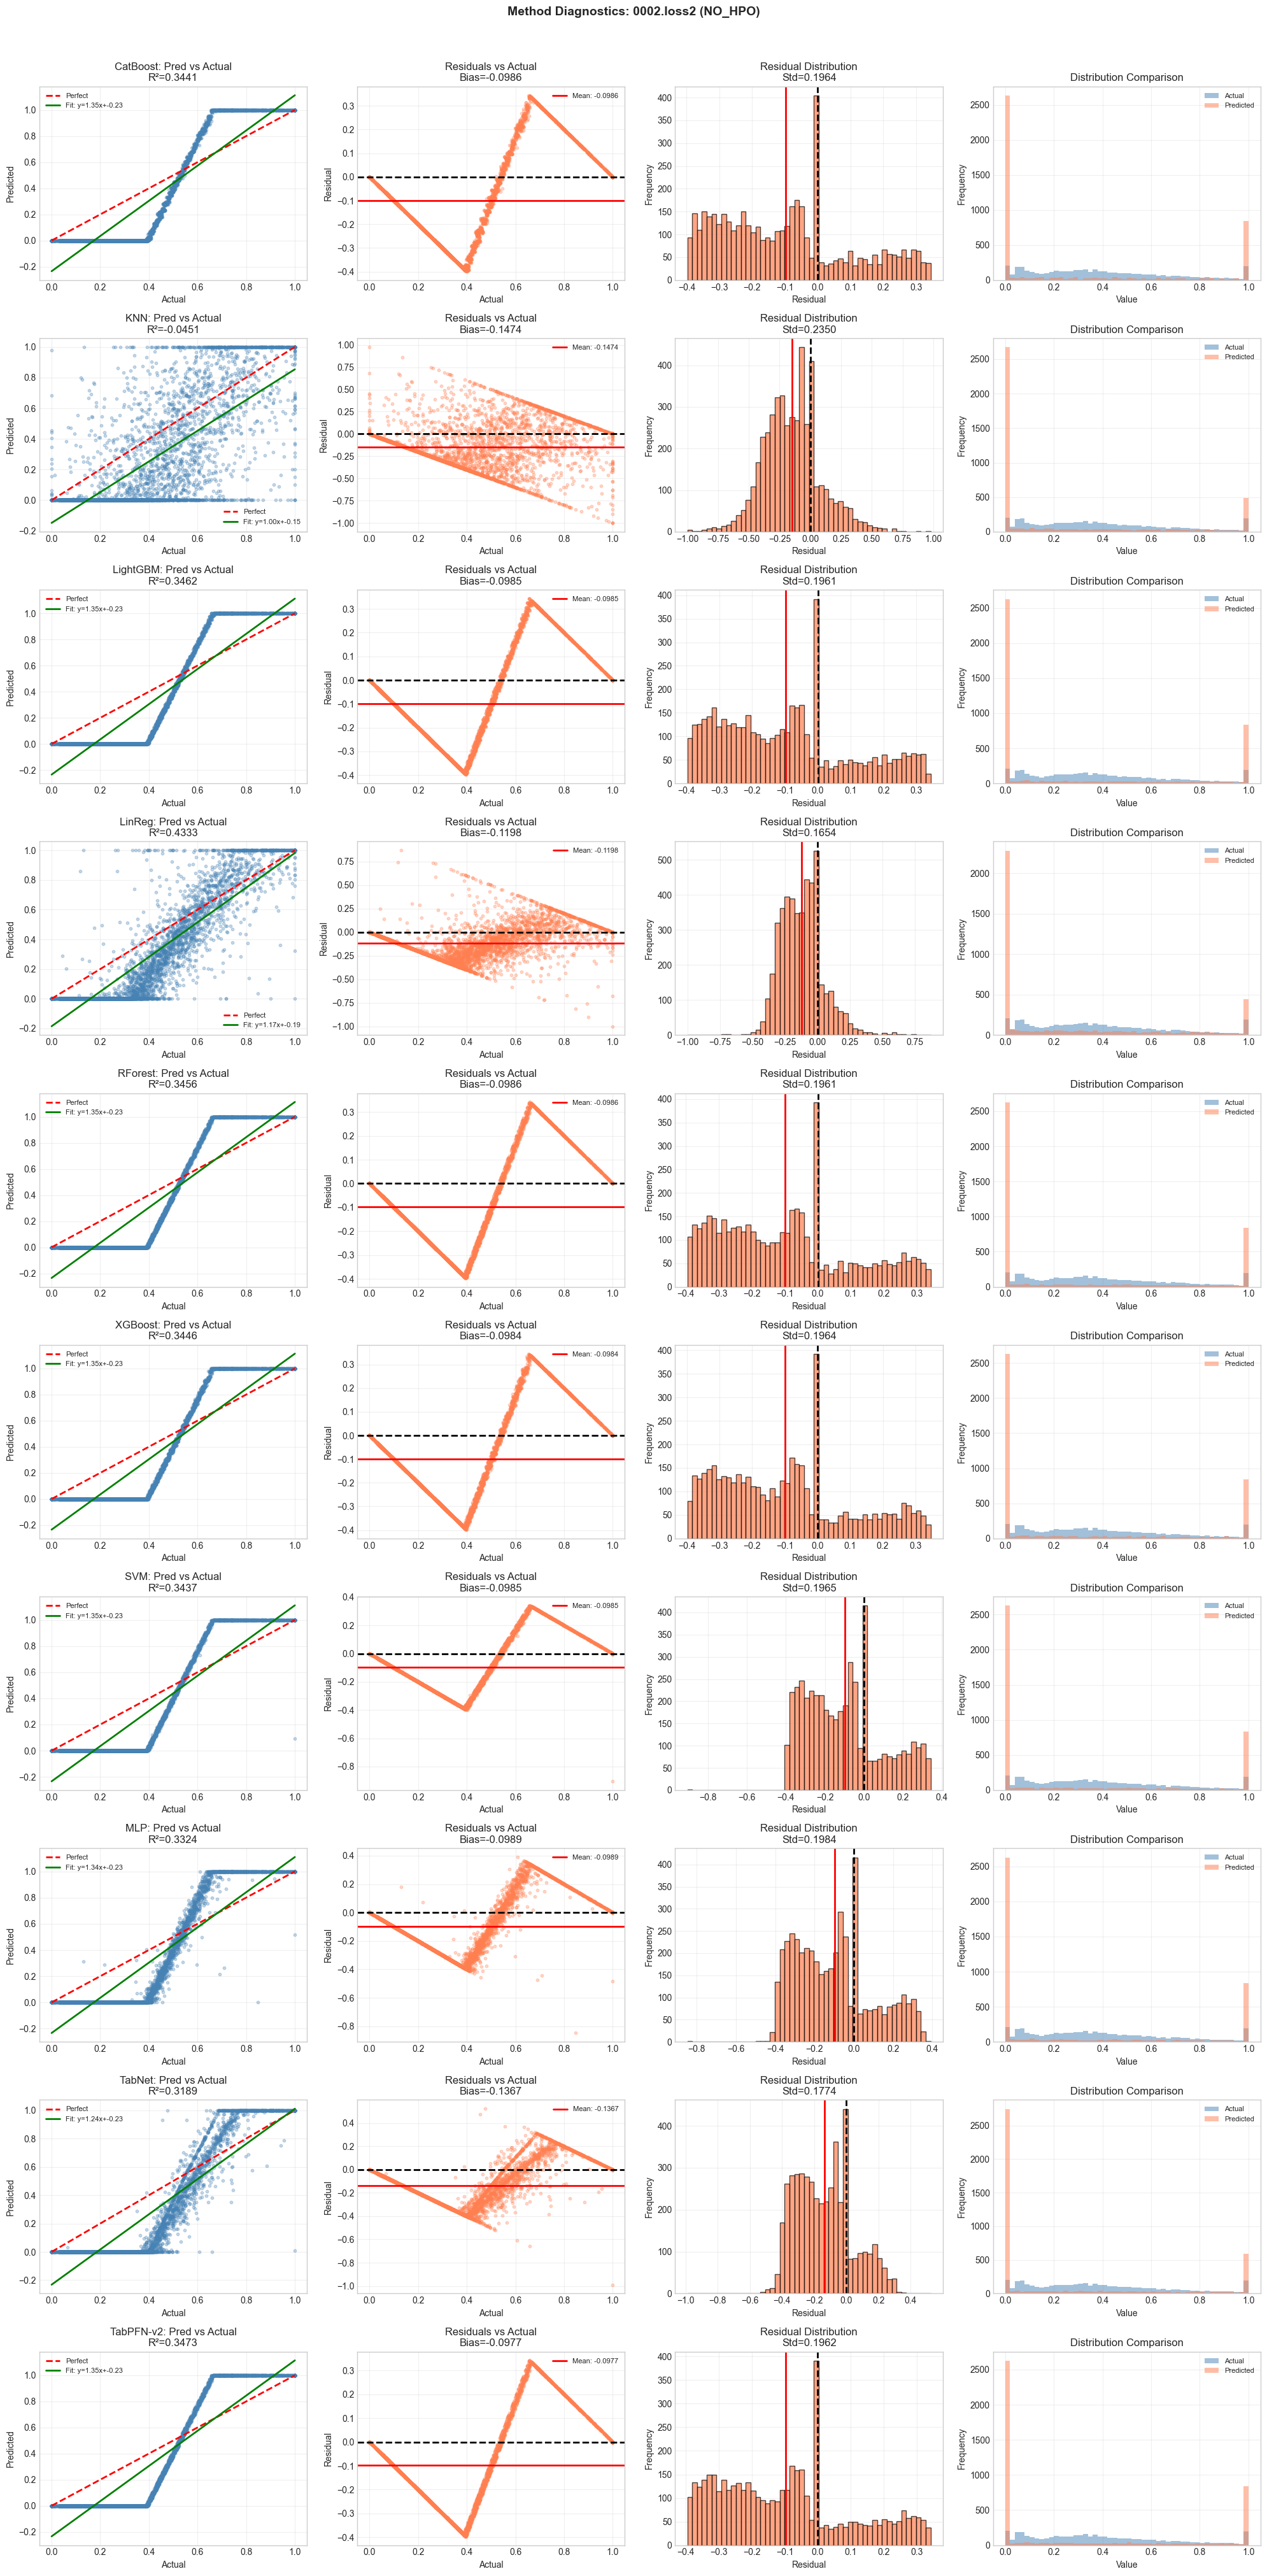

In [22]:
print_section("7. METHOD-BY-METHOD VISUALIZATION")

def plot_method_diagnostics(results_dir, dataset, hpo_mode='NO_HPO'):
    """Create diagnostic plots for each method."""
    
    data = load_pickle(results_dir / f"{dataset}.pkl")
    
    if hpo_mode not in data:
        print(f"HPO mode '{hpo_mode}' not found")
        return
    
    methods = list(data[hpo_mode].keys())
    n_methods = len(methods)
    
    if n_methods == 0:
        print("No methods found")
        return
    
    fig, axes = plt.subplots(n_methods, 4, figsize=(20, 4*n_methods))
    if n_methods == 1:
        axes = axes.reshape(1, -1)
    
    for idx, method in enumerate(methods):
        all_y_true = []
        all_y_pred_raw = []
        all_y_pred = []
        
        for fold_data in data[hpo_mode][method].values():
            all_y_true.extend(np.asarray(fold_data['y_true']).ravel())
            if 'y_pred_raw' in fold_data:
                all_y_pred_raw.extend(np.asarray(fold_data['y_pred_raw']).ravel())
            if 'y_pred' in fold_data:
                all_y_pred.extend(np.asarray(fold_data['y_pred']).ravel())
        
        y_true = np.array(all_y_true)
        y_pred_raw = np.array(all_y_pred_raw) if all_y_pred_raw else None
        y_pred = np.array(all_y_pred) if all_y_pred else y_pred_raw
        
        if y_pred is None:
            continue
        
        # Plot 1: Scatter (Predicted vs Actual)
        ax1 = axes[idx, 0]
        ax1.scatter(y_true, y_pred, alpha=0.3, s=10, c='steelblue')
        ax1.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect')
        
        # Add regression line
        if np.std(y_true) > 0 and np.std(y_pred) > 0:
            z = np.polyfit(y_true, y_pred, 1)
            p = np.poly1d(z)
            ax1.plot([y_true.min(), y_true.max()], 
                    [p(y_true.min()), p(y_true.max())], 
                    'g-', linewidth=2, label=f'Fit: y={z[0]:.2f}x+{z[1]:.2f}')
        
        r2 = r2_score(y_true, y_pred) if len(y_true) > 1 else np.nan
        ax1.set_xlabel('Actual')
        ax1.set_ylabel('Predicted')
        ax1.set_title(f'{get_display_name(method)}: Pred vs Actual\nR²={r2:.4f}')
        ax1.legend(fontsize=8)
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Residuals vs Actual
        ax2 = axes[idx, 1]
        residuals = y_pred - y_true
        ax2.scatter(y_true, residuals, alpha=0.3, s=10, c='coral')
        ax2.axhline(0, color='black', linestyle='--', linewidth=2)
        ax2.axhline(residuals.mean(), color='red', linestyle='-', linewidth=2,
                   label=f'Mean: {residuals.mean():.4f}')
        ax2.set_xlabel('Actual')
        ax2.set_ylabel('Residual')
        ax2.set_title(f'Residuals vs Actual\nBias={residuals.mean():.4f}')
        ax2.legend(fontsize=8)
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Residual Distribution
        ax3 = axes[idx, 2]
        ax3.hist(residuals, bins=50, alpha=0.7, color='coral', edgecolor='black')
        ax3.axvline(0, color='black', linestyle='--', linewidth=2)
        ax3.axvline(residuals.mean(), color='red', linestyle='-', linewidth=2)
        ax3.set_xlabel('Residual')
        ax3.set_ylabel('Frequency')
        ax3.set_title(f'Residual Distribution\nStd={residuals.std():.4f}')
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Prediction Distribution Comparison
        ax4 = axes[idx, 3]
        ax4.hist(y_true, bins=50, alpha=0.5, label='Actual', color='steelblue')
        ax4.hist(y_pred, bins=50, alpha=0.5, label='Predicted', color='coral')
        ax4.set_xlabel('Value')
        ax4.set_ylabel('Frequency')
        ax4.set_title(f'Distribution Comparison')
        ax4.legend(fontsize=8)
        ax4.grid(True, alpha=0.3)
    
    plt.suptitle(f'Method Diagnostics: {dataset} ({hpo_mode})', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


if lgd_datasets:
    dataset = lgd_datasets[1] # Change index as needed
    print(f"Creating diagnostic plots for: {dataset}")
    plot_method_diagnostics(LGD_RESULTS_DIR, dataset, 'NO_HPO')

## 8. Clipping Impact Analysis

The `method_runner.py` clips LGD predictions to [0, 1]. Let's analyze:
1. How many predictions are clipped?
2. Does clipping help or hurt?
3. Would clipping to [min(y_true), max(y_true)] be better?

In [10]:
print_section("8. CLIPPING IMPACT ANALYSIS")

def analyze_clipping_impact(results_dir, datasets, hpo_mode='NO_HPO'):
    """Analyze how clipping affects predictions."""
    
    all_clipping_data = []
    
    for dataset in datasets:
        data = load_pickle(results_dir / f"{dataset}.pkl")
        
        if hpo_mode not in data:
            continue
        
        for method in data[hpo_mode]:
            all_y_true = []
            all_y_pred_raw = []
            n_below = 0
            n_above = 0
            
            for fold_data in data[hpo_mode][method].values():
                y_true = np.asarray(fold_data['y_true']).ravel()
                all_y_true.extend(y_true)
                
                if 'y_pred_raw' in fold_data:
                    y_pred_raw = np.asarray(fold_data['y_pred_raw']).ravel()
                    all_y_pred_raw.extend(y_pred_raw)
                
                if 'n_clipped_below' in fold_data:
                    n_below += fold_data['n_clipped_below']
                if 'n_clipped_above' in fold_data:
                    n_above += fold_data['n_clipped_above']
            
            if not all_y_pred_raw:
                continue
            
            y_true = np.array(all_y_true)
            y_pred_raw = np.array(all_y_pred_raw)
            
            # Calculate metrics with different clipping strategies
            y_pred_01 = np.clip(y_pred_raw, 0, 1)
            y_pred_target = np.clip(y_pred_raw, y_true.min(), y_true.max())
            
            metrics_raw = calculate_metrics(y_true, y_pred_raw)
            metrics_01 = calculate_metrics(y_true, y_pred_01)
            metrics_target = calculate_metrics(y_true, y_pred_target)
            
            all_clipping_data.append({
                'Dataset': dataset,
                'Method': get_display_name(method),
                'N': len(y_true),
                'Pred_Min': y_pred_raw.min(),
                'Pred_Max': y_pred_raw.max(),
                'Below_0': n_below,
                'Above_1': n_above,
                'Clipped_Pct': 100 * (n_below + n_above) / len(y_true),
                'R2_Raw': metrics_raw['R2'],
                'R2_01': metrics_01['R2'],
                'R2_Target': metrics_target['R2'],
                'RMSE_Raw': metrics_raw['RMSE'],
                'RMSE_01': metrics_01['RMSE'],
                'RMSE_Target': metrics_target['RMSE'],
            })
    
    return pd.DataFrame(all_clipping_data)


if lgd_datasets:
    clipping_df = analyze_clipping_impact(LGD_RESULTS_DIR, lgd_datasets, 'NO_HPO')
    
    if not clipping_df.empty:
        print("📊 CLIPPING IMPACT SUMMARY:")
        print("-" * 120)
        
        # Show high-clipping methods
        high_clip = clipping_df[clipping_df['Clipped_Pct'] > 5]
        if not high_clip.empty:
            print("\n⚠️ Methods with >5% clipping:")
            display(high_clip[['Dataset', 'Method', 'Clipped_Pct', 'Below_0', 'Above_1', 
                              'Pred_Min', 'Pred_Max']].round(4))
        
        # Compare clipping strategies
        print("\n📈 R² by Clipping Strategy (averaged across datasets):")
        avg_by_method = clipping_df.groupby('Method').agg({
            'R2_Raw': 'mean',
            'R2_01': 'mean',
            'R2_Target': 'mean',
            'Clipped_Pct': 'mean',
        }).round(4)
        avg_by_method.columns = ['R² Raw', 'R² [0,1]', 'R² Target', 'Clipped %']
        display(avg_by_method)


  8. CLIPPING IMPACT ANALYSIS

📊 CLIPPING IMPACT SUMMARY:
------------------------------------------------------------------------------------------------------------------------

⚠️ Methods with >5% clipping:


,Dataset,Method,Clipped_Pct,Below_0,Above_1,Pred_Min,Pred_Max
0,0001.heloc,CatBoost,31.8345,21563,52,-2.2921,3.5032
1,0001.heloc,KNN,35.1174,23806,38,-1.6299,5.3600
2,0001.heloc,LightGBM,33.7300,22686,216,-2.7200,4.8858
3,0001.heloc,LinReg,27.2497,18490,12,-2.6774,3.6562
4,0001.heloc,RForest,30.9405,20986,22,-1.5769,4.7949
5,0001.heloc,XGBoost,35.9466,23390,1017,-2.9456,5.4111
6,0001.heloc,SVM,15.3318,10410,0,-1.6140,0.7635
7,0001.heloc,MLP,29.4088,19936,32,-2.6299,1.6531
8,0001.heloc,TabNet,33.3986,22677,0,-3.6153,0.8148
9,0001.heloc,TabPFN-v2,22.2320,11116,0,-1.3819,0.7787



📈 R² by Clipping Strategy (averaged across datasets):


,R² Raw,"R² [0,1]",R² Target,Clipped %
Method,,,,
CatBoost,-2.8884,0.0062,0.0013,62.1838
KNN,-3.5421,-0.1922,-0.1993,61.3173
LightGBM,-3.7712,-0.0062,-0.0090,64.4067
LinReg,-5973.2723,-0.1942,-0.2022,53.4191
MLP,-1261.5788,-0.1197,-0.1259,61.2285
RForest,-3.1521,-0.0440,-0.0476,62.7579
SVM,-354.4146,-0.1038,-0.1055,73.9566
TabNet,-757.3862,-0.2191,-0.2280,62.2840
TabPFN-v2,-2.7329,0.0736,0.0725,63.5098


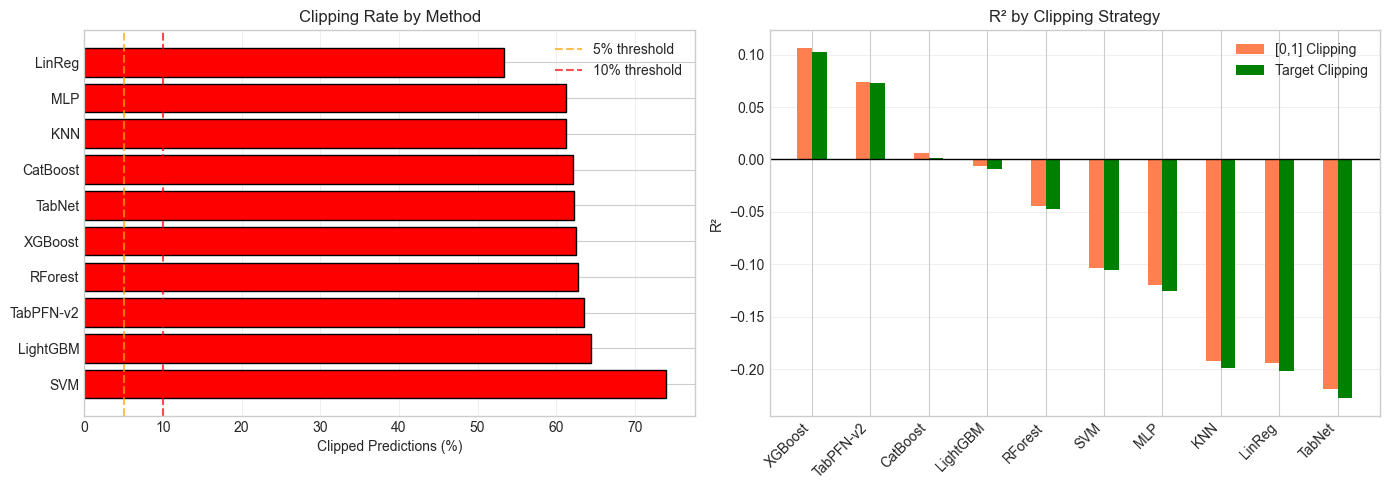

In [11]:
# Visualize clipping impact
if 'clipping_df' in dir() and clipping_df is not None and not clipping_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Clipping percentage by method
    ax1 = axes[0]
    method_clip = clipping_df.groupby('Method')['Clipped_Pct'].mean().sort_values(ascending=False)
    colors = ['red' if v > 10 else 'orange' if v > 5 else 'green' for v in method_clip.values]
    ax1.barh(range(len(method_clip)), method_clip.values, color=colors, edgecolor='black')
    ax1.set_yticks(range(len(method_clip)))
    ax1.set_yticklabels(method_clip.index)
    ax1.set_xlabel('Clipped Predictions (%)')
    ax1.set_title('Clipping Rate by Method')
    ax1.axvline(5, color='orange', linestyle='--', alpha=0.7, label='5% threshold')
    ax1.axvline(10, color='red', linestyle='--', alpha=0.7, label='10% threshold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Plot 2: R² comparison
    ax2 = axes[1]
    methods = clipping_df.groupby('Method')['R2_01'].mean().sort_values(ascending=False).index
    x = np.arange(len(methods))
    width = 0.25
    
    r2_01 = [clipping_df[clipping_df['Method'] == m]['R2_01'].mean() for m in methods]
    r2_target = [clipping_df[clipping_df['Method'] == m]['R2_Target'].mean() for m in methods]
    
    ax2.bar(x - width/2, r2_01, width, label='[0,1] Clipping', color='coral')
    ax2.bar(x + width/2, r2_target, width, label='Target Clipping', color='green')
    ax2.set_xticks(x)
    ax2.set_xticklabels(methods, rotation=45, ha='right')
    ax2.set_ylabel('R²')
    ax2.set_title('R² by Clipping Strategy')
    ax2.legend()
    ax2.axhline(0, color='black', linestyle='-', linewidth=1)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

## 9. Variance Analysis - Is the Model Predicting Constants?

A common failure mode is when models collapse to predicting near-constant values (e.g., always predicting the mean). This results in:
- Very low prediction variance
- R² close to 0 or negative
- Good RMSE but no discriminative power

In [12]:
print_section("9. VARIANCE ANALYSIS - Is the model predicting constants?")

def analyze_prediction_variance(results_dir, datasets, hpo_mode='NO_HPO'):
    """Check if models are predicting near-constant values."""
    
    variance_data = []
    
    for dataset in datasets:
        data = load_pickle(results_dir / f"{dataset}.pkl")
        
        if hpo_mode not in data:
            continue
        
        for method in data[hpo_mode]:
            all_y_true = []
            all_y_pred = []
            
            for fold_data in data[hpo_mode][method].values():
                all_y_true.extend(np.asarray(fold_data['y_true']).ravel())
                if 'y_pred' in fold_data:
                    all_y_pred.extend(np.asarray(fold_data['y_pred']).ravel())
                elif 'y_pred_raw' in fold_data:
                    all_y_pred.extend(np.asarray(fold_data['y_pred_raw']).ravel())
            
            if not all_y_pred:
                continue
            
            y_true = np.array(all_y_true)
            y_pred = np.array(all_y_pred)
            
            # Calculate variance metrics
            true_var = np.var(y_true)
            pred_var = np.var(y_pred)
            pred_range = y_pred.max() - y_pred.min()
            pred_unique = len(np.unique(y_pred.round(4)))
            
            # Check if essentially constant
            is_constant = pred_var < 1e-6 or pred_range < 0.01
            is_low_variance = pred_var < 0.1 * true_var
            
            variance_data.append({
                'Dataset': dataset,
                'Method': get_display_name(method),
                'True_Var': true_var,
                'Pred_Var': pred_var,
                'Var_Ratio': pred_var / (true_var + 1e-10),
                'Pred_Range': pred_range,
                'Pred_Unique': pred_unique,
                'Is_Constant': is_constant,
                'Is_Low_Var': is_low_variance,
            })
    
    return pd.DataFrame(variance_data)


if lgd_datasets:
    variance_df = analyze_prediction_variance(LGD_RESULTS_DIR, lgd_datasets, 'NO_HPO')
    
    if not variance_df.empty:
        print("📊 PREDICTION VARIANCE ANALYSIS:")
        print("-" * 100)
        display(variance_df[['Dataset', 'Method', 'True_Var', 'Pred_Var', 'Var_Ratio', 
                            'Pred_Range', 'Is_Constant', 'Is_Low_Var']].round(6))
        
        # Identify problematic methods
        constant_methods = variance_df[variance_df['Is_Constant']]
        low_var_methods = variance_df[variance_df['Is_Low_Var'] & ~variance_df['Is_Constant']]
        
        print("\n⚠️ VARIANCE ISSUES:")
        print("-" * 50)
        
        if not constant_methods.empty:
            print("\n🔴 Methods predicting NEAR-CONSTANT values:")
            for _, row in constant_methods.iterrows():
                print(f"   {row['Dataset']}/{row['Method']}: Range={row['Pred_Range']:.6f}, Var={row['Pred_Var']:.6f}")
        
        if not low_var_methods.empty:
            print("\n🟡 Methods with LOW variance (< 10% of target variance):")
            for _, row in low_var_methods.iterrows():
                print(f"   {row['Dataset']}/{row['Method']}: Var ratio={row['Var_Ratio']:.4f}")
        
        if constant_methods.empty and low_var_methods.empty:
            print("   ✅ No constant or low-variance predictions detected")


  9. VARIANCE ANALYSIS - Is the model predicting constants?

📊 PREDICTION VARIANCE ANALYSIS:
----------------------------------------------------------------------------------------------------


,Dataset,Method,True_Var,Pred_Var,Var_Ratio,Pred_Range,Is_Constant,Is_Low_Var
0,0001.heloc,CatBoost,0.186291,0.064308,0.345202,1.000000,False,False
1,0001.heloc,KNN,0.186291,0.106043,0.569234,1.000000,False,False
2,0001.heloc,LightGBM,0.186291,0.097100,0.521226,1.000000,False,False
3,0001.heloc,LinReg,0.186291,0.035531,0.190729,1.000000,False,False
4,0001.heloc,RForest,0.186291,0.059328,0.318468,1.000000,False,False
5,0001.heloc,XGBoost,0.186291,0.117133,0.628766,1.000000,False,False
6,0001.heloc,SVM,0.186291,0.072728,0.390401,0.763462,False,False
7,0001.heloc,MLP,0.186291,0.061794,0.331708,1.000000,False,False
8,0001.heloc,TabNet,0.186291,0.044021,0.236304,0.814751,False,False
9,0001.heloc,TabPFN-v2,0.206563,0.054953,0.266037,0.778734,False,False



⚠️ VARIANCE ISSUES:
--------------------------------------------------

🟡 Methods with LOW variance (< 10% of target variance):
   0003.axa/SVM: Var ratio=0.0612
   0004.base_model/SVM: Var ratio=0.0425


## 10. Comparison: LGD vs PD Performance

Compare how the same methods perform on PD (classification) vs LGD (regression) to understand if the problem is:
- Method-specific (e.g., method doesn't work for regression)
- Data-specific (e.g., LGD task is inherently harder)
- Configuration-specific (e.g., wrong hyperparameters for regression)

In [13]:
print_section("10. LGD vs PD PERFORMANCE COMPARISON")

def compare_lgd_pd(lgd_dir, pd_dir, hpo_mode='NO_HPO'):
    """Compare performance between LGD and PD tasks."""
    
    lgd_datasets = list_datasets(lgd_dir)
    pd_datasets = list_datasets(pd_dir)
    
    common_datasets = set(lgd_datasets) & set(pd_datasets)
    
    if not common_datasets:
        print("No common datasets between LGD and PD")
        return None, None
    
    lgd_results = []
    pd_results = []
    
    for dataset in common_datasets:
        # LGD
        lgd_data = load_pickle(lgd_dir / f"{dataset}.pkl")
        if hpo_mode in lgd_data:
            for method in lgd_data[hpo_mode]:
                metrics_list = []
                for fold_data in lgd_data[hpo_mode][method].values():
                    if 'metrics' in fold_data:
                        metrics_list.append(fold_data['metrics'])
                
                if metrics_list:
                    avg_r2 = np.mean([m.get('R2', np.nan) for m in metrics_list])
                    avg_rmse = np.mean([m.get('RMSE', np.nan) for m in metrics_list])
                    lgd_results.append({
                        'Dataset': dataset,
                        'Method': method,
                        'R2': avg_r2,
                        'RMSE': avg_rmse,
                    })
        
        # PD
        pd_data = load_pickle(pd_dir / f"{dataset}.pkl")
        if hpo_mode in pd_data:
            for method in pd_data[hpo_mode]:
                metrics_list = []
                for fold_data in pd_data[hpo_mode][method].values():
                    if 'metrics' in fold_data:
                        metrics_list.append(fold_data['metrics'])
                
                if metrics_list:
                    avg_auc = np.mean([m.get('AUC', np.nan) for m in metrics_list])
                    avg_f1 = np.mean([m.get('F1', np.nan) for m in metrics_list])
                    pd_results.append({
                        'Dataset': dataset,
                        'Method': method,
                        'AUC': avg_auc,
                        'F1': avg_f1,
                    })
    
    return pd.DataFrame(lgd_results), pd.DataFrame(pd_results)


if LGD_RESULTS_DIR.exists() and PD_RESULTS_DIR.exists():
    lgd_perf, pd_perf = compare_lgd_pd(LGD_RESULTS_DIR, PD_RESULTS_DIR, 'NO_HPO')
    
    if lgd_perf is not None and not lgd_perf.empty and pd_perf is not None and not pd_perf.empty:
        # Average by method
        lgd_avg = lgd_perf.groupby('Method').agg({'R2': 'mean', 'RMSE': 'mean'}).round(4)
        pd_avg = pd_perf.groupby('Method').agg({'AUC': 'mean', 'F1': 'mean'}).round(4)
        
        print("📊 LGD PERFORMANCE (R² by method):")
        print("-" * 60)
        display(lgd_avg.sort_values('R2', ascending=False))
        
        print("\n📊 PD PERFORMANCE (AUC by method):")
        print("-" * 60)
        display(pd_avg.sort_values('AUC', ascending=False))
        
        # Compare relative performance
        print("\n📈 RELATIVE PERFORMANCE COMPARISON:")
        print("-" * 60)
        
        common_methods = set(lgd_avg.index) & set(pd_avg.index)
        for method in sorted(common_methods):
            lgd_r2 = lgd_avg.loc[method, 'R2']
            pd_auc = pd_avg.loc[method, 'AUC']
            
            # Normalize: R² can be negative, AUC is 0.5-1.0
            lgd_score = max(0, lgd_r2)  # Treat negative R² as 0
            pd_score = (pd_auc - 0.5) * 2  # Scale AUC: 0.5->0, 1.0->1
            
            diff = lgd_score - pd_score
            indicator = "🟢" if diff > -0.1 else "🟡" if diff > -0.3 else "🔴"
            
            print(f"   {indicator} {get_display_name(method):15}: LGD R²={lgd_r2:+.4f}, PD AUC={pd_auc:.4f}")
else:
    print("⚠️ Both LGD and PD results directories needed for comparison")


  10. LGD vs PD PERFORMANCE COMPARISON

No common datasets between LGD and PD


In [14]:
# Visualization: LGD vs PD
if 'lgd_perf' in dir() and lgd_perf is not None and not lgd_perf.empty:
    if 'pd_perf' in dir() and pd_perf is not None and not pd_perf.empty:
        
        lgd_avg = lgd_perf.groupby('Method')['R2'].mean()
        pd_avg = pd_perf.groupby('Method')['AUC'].mean()
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # LGD R² distribution
        ax1 = axes[0]
        methods_sorted = lgd_avg.sort_values(ascending=False).index
        colors = ['green' if v > 0.1 else 'orange' if v > 0 else 'red' for v in lgd_avg.loc[methods_sorted]]
        ax1.barh(range(len(methods_sorted)), lgd_avg.loc[methods_sorted].values, color=colors, edgecolor='black')
        ax1.set_yticks(range(len(methods_sorted)))
        ax1.set_yticklabels([get_display_name(m) for m in methods_sorted])
        ax1.set_xlabel('R²')
        ax1.set_title('LGD Performance (R²)')
        ax1.axvline(0, color='black', linestyle='-', linewidth=2)
        ax1.grid(True, alpha=0.3, axis='x')
        
        # PD AUC distribution
        ax2 = axes[1]
        methods_sorted = pd_avg.sort_values(ascending=False).index
        colors = ['green' if v > 0.7 else 'orange' if v > 0.6 else 'red' for v in pd_avg.loc[methods_sorted]]
        ax2.barh(range(len(methods_sorted)), pd_avg.loc[methods_sorted].values, color=colors, edgecolor='black')
        ax2.set_yticks(range(len(methods_sorted)))
        ax2.set_yticklabels([get_display_name(m) for m in methods_sorted])
        ax2.set_xlabel('AUC')
        ax2.set_title('PD Performance (AUC)')
        ax2.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Random')
        ax2.set_xlim(0.4, 1.0)
        ax2.grid(True, alpha=0.3, axis='x')
        ax2.legend()
        
        plt.tight_layout()
        plt.show()

## 11. Per-Fold Consistency Analysis

Check if performance is consistent across folds or highly variable (indicating instability or data issues).

In [15]:
print_section("11. PER-FOLD CONSISTENCY ANALYSIS")

def analyze_fold_consistency(results_dir, dataset, hpo_mode='NO_HPO'):
    """Analyze how consistent predictions are across folds."""
    
    data = load_pickle(results_dir / f"{dataset}.pkl")
    
    if hpo_mode not in data:
        return None
    
    consistency_data = []
    
    for method in data[hpo_mode]:
        fold_metrics = []
        
        for fold_id, fold_data in data[hpo_mode][method].items():
            y_true = np.asarray(fold_data['y_true']).ravel()
            y_pred = np.asarray(fold_data.get('y_pred', fold_data.get('y_pred_raw', []))).ravel()
            
            if len(y_pred) == 0:
                continue
            
            metrics = calculate_metrics(y_true, y_pred)
            metrics['fold'] = fold_id
            fold_metrics.append(metrics)
        
        if fold_metrics:
            r2_values = [m['R2'] for m in fold_metrics]
            rmse_values = [m['RMSE'] for m in fold_metrics]
            
            consistency_data.append({
                'Method': get_display_name(method),
                'N_Folds': len(fold_metrics),
                'R2_Mean': np.mean(r2_values),
                'R2_Std': np.std(r2_values),
                'R2_Min': np.min(r2_values),
                'R2_Max': np.max(r2_values),
                'R2_Range': np.max(r2_values) - np.min(r2_values),
                'RMSE_Mean': np.mean(rmse_values),
                'RMSE_Std': np.std(rmse_values),
            })
    
    return pd.DataFrame(consistency_data)


if lgd_datasets:
    dataset = lgd_datasets[0]
    consistency_df = analyze_fold_consistency(LGD_RESULTS_DIR, dataset, 'NO_HPO')
    
    if consistency_df is not None and not consistency_df.empty:
        print(f"📊 FOLD CONSISTENCY FOR: {dataset}")
        print("-" * 100)
        display(consistency_df.round(4))
        
        # Identify inconsistent methods
        print("\n⚠️ CONSISTENCY ISSUES:")
        print("-" * 50)
        issues_found = False
        
        high_variance = consistency_df[consistency_df['R2_Std'] > 0.1]
        if not high_variance.empty:
            issues_found = True
            print("Methods with high R² variance (Std > 0.1):")
            for _, row in high_variance.iterrows():
                print(f"   {row['Method']}: R² = {row['R2_Mean']:.4f} ± {row['R2_Std']:.4f}")
        
        wide_range = consistency_df[consistency_df['R2_Range'] > 0.2]
        if not wide_range.empty:
            issues_found = True
            print("\nMethods with wide R² range (> 0.2):")
            for _, row in wide_range.iterrows():
                print(f"   {row['Method']}: Range = [{row['R2_Min']:.4f}, {row['R2_Max']:.4f}]")
        
        if not issues_found:
            print("   ✅ All methods show consistent performance across folds")


  11. PER-FOLD CONSISTENCY ANALYSIS

📊 FOLD CONSISTENCY FOR: 0001.heloc
----------------------------------------------------------------------------------------------------


,Method,N_Folds,R2_Mean,R2_Std,R2_Min,R2_Max,R2_Range,RMSE_Mean,RMSE_Std
0,CatBoost,5,-0.3944,0.0213,-0.4265,-0.3643,0.0623,0.5096,0.0028
1,KNN,5,-0.0497,0.0113,-0.0694,-0.0384,0.0310,0.4422,0.0014
2,LightGBM,5,0.1361,0.0094,0.1200,0.1487,0.0286,0.4012,0.0025
3,LinReg,5,-0.9776,0.0161,-0.9993,-0.9543,0.0450,0.6069,0.0016
4,RForest,5,-0.3224,0.0144,-0.3435,-0.3027,0.0408,0.4963,0.0015
5,XGBoost,5,0.2502,0.0065,0.2393,0.2587,0.0194,0.3737,0.0013
6,SVM,5,0.1859,0.0039,0.1792,0.1896,0.0104,0.3894,0.0009
7,MLP,5,-0.4546,0.0414,-0.5051,-0.4065,0.0986,0.5205,0.0069
8,TabNet,5,-0.7842,0.0669,-0.9054,-0.7234,0.1820,0.5764,0.0106
9,TabPFN-v2,5,0.0020,0.0678,-0.1209,0.0826,0.2035,0.4537,0.0135



⚠️ CONSISTENCY ISSUES:
--------------------------------------------------

Methods with wide R² range (> 0.2):
   TabPFN-v2: Range = [-0.1209, 0.0826]


## 12. Baseline Comparison - Are Models Better Than Predicting the Mean?

The simplest baseline for regression is predicting the mean. If models can't beat this, there's a fundamental problem.

In [16]:
print_section("12. BASELINE COMPARISON - Are models better than predicting mean?")

def compare_to_baseline(results_dir, datasets, hpo_mode='NO_HPO'):
    """Compare model performance to simple mean baseline."""
    
    baseline_data = []
    
    for dataset in datasets:
        data = load_pickle(results_dir / f"{dataset}.pkl")
        
        if hpo_mode not in data:
            continue
        
        for method in data[hpo_mode]:
            all_y_true = []
            all_y_pred = []
            
            for fold_data in data[hpo_mode][method].values():
                all_y_true.extend(np.asarray(fold_data['y_true']).ravel())
                y_pred = fold_data.get('y_pred', fold_data.get('y_pred_raw'))
                if y_pred is not None:
                    all_y_pred.extend(np.asarray(y_pred).ravel())
            
            if not all_y_pred:
                continue
            
            y_true = np.array(all_y_true)
            y_pred = np.array(all_y_pred)
            
            # Model metrics
            model_mse = mean_squared_error(y_true, y_pred)
            model_r2 = r2_score(y_true, y_pred)
            
            # Baseline: predict mean
            y_mean = np.full_like(y_true, y_true.mean())
            baseline_mse = mean_squared_error(y_true, y_mean)
            
            # Baseline: predict median
            y_median = np.full_like(y_true, np.median(y_true))
            median_mse = mean_squared_error(y_true, y_median)
            
            # Compare
            better_than_mean = model_mse < baseline_mse
            mse_improvement = (baseline_mse - model_mse) / baseline_mse * 100
            
            baseline_data.append({
                'Dataset': dataset,
                'Method': get_display_name(method),
                'Model_MSE': model_mse,
                'Model_R2': model_r2,
                'Mean_MSE': baseline_mse,
                'Median_MSE': median_mse,
                'Better_Than_Mean': better_than_mean,
                'MSE_Improvement_%': mse_improvement,
            })
    
    return pd.DataFrame(baseline_data)


if lgd_datasets:
    baseline_df = compare_to_baseline(LGD_RESULTS_DIR, lgd_datasets, 'NO_HPO')
    
    if not baseline_df.empty:
        print("📊 BASELINE COMPARISON:")
        print("-" * 100)
        display(baseline_df[['Dataset', 'Method', 'Model_R2', 'Model_MSE', 'Mean_MSE', 
                            'Better_Than_Mean', 'MSE_Improvement_%']].round(4))
        
        # Summary
        n_better = baseline_df['Better_Than_Mean'].sum()
        n_total = len(baseline_df)
        pct_better = 100 * n_better / n_total
        
        print(f"\n📈 SUMMARY:")
        print("-" * 50)
        print(f"   Models better than mean baseline: {n_better}/{n_total} ({pct_better:.1f}%)")
        
        # Methods that beat baseline
        by_method = baseline_df.groupby('Method').agg({
            'Better_Than_Mean': 'mean',
            'MSE_Improvement_%': 'mean',
            'Model_R2': 'mean'
        }).round(4)
        by_method.columns = ['Win_Rate', 'Avg_Improvement_%', 'Avg_R2']
        by_method = by_method.sort_values('Win_Rate', ascending=False)
        
        print("\n📊 Method Win Rate vs Mean Baseline:")
        display(by_method)
        
        # Worst performers
        worse_than_mean = baseline_df[~baseline_df['Better_Than_Mean']]
        if not worse_than_mean.empty:
            print("\n🔴 Methods WORSE than mean baseline:")
            for _, row in worse_than_mean.iterrows():
                print(f"   {row['Dataset']}/{row['Method']}: R²={row['Model_R2']:.4f}, "
                      f"Model MSE={row['Model_MSE']:.4f} > Mean MSE={row['Mean_MSE']:.4f}")


  12. BASELINE COMPARISON - Are models better than predicting mean?

📊 BASELINE COMPARISON:
----------------------------------------------------------------------------------------------------


,Dataset,Method,Model_R2,Model_MSE,Mean_MSE,Better_Than_Mean,MSE_Improvement_%
0,0001.heloc,CatBoost,-0.3942,0.2597,0.1863,False,-39.4213
1,0001.heloc,KNN,-0.0496,0.1955,0.1863,False,-4.9559
2,0001.heloc,LightGBM,0.1361,0.1609,0.1863,True,13.6121
3,0001.heloc,LinReg,-0.9775,0.3684,0.1863,False,-97.7482
4,0001.heloc,RForest,-0.3222,0.2463,0.1863,False,-32.2246
5,0001.heloc,XGBoost,0.2503,0.1397,0.1863,True,25.0295
6,0001.heloc,SVM,0.1859,0.1517,0.1863,True,18.5924
7,0001.heloc,MLP,-0.4544,0.2709,0.1863,False,-45.4427
8,0001.heloc,TabNet,-0.7840,0.3324,0.1863,False,-78.4039
9,0001.heloc,TabPFN-v2,0.0026,0.2060,0.2066,True,0.2623



📈 SUMMARY:
--------------------------------------------------
   Models better than mean baseline: 23/50 (46.0%)

📊 Method Win Rate vs Mean Baseline:


,Win_Rate,Avg_Improvement_%,Avg_R2
Method,,,
LinReg,0.6,-19.4207,-0.1942
LightGBM,0.6,-0.6172,-0.0062
XGBoost,0.6,10.6330,0.1063
SVM,0.6,-10.3768,-0.1038
TabPFN-v2,0.6,7.3568,0.0736
CatBoost,0.4,0.6188,0.0062
RForest,0.4,-4.3971,-0.0440
MLP,0.4,-11.9698,-0.1197
TabNet,0.4,-21.9128,-0.2191



🔴 Methods WORSE than mean baseline:
   0001.heloc/CatBoost: R²=-0.3942, Model MSE=0.2597 > Mean MSE=0.1863
   0001.heloc/KNN: R²=-0.0496, Model MSE=0.1955 > Mean MSE=0.1863
   0001.heloc/LinReg: R²=-0.9775, Model MSE=0.3684 > Mean MSE=0.1863
   0001.heloc/RForest: R²=-0.3222, Model MSE=0.2463 > Mean MSE=0.1863
   0001.heloc/MLP: R²=-0.4544, Model MSE=0.2709 > Mean MSE=0.1863
   0001.heloc/TabNet: R²=-0.7840, Model MSE=0.3324 > Mean MSE=0.1863
   0002.loss2/KNN: R²=-0.0451, Model MSE=0.0769 > Mean MSE=0.0736
   0003.axa/CatBoost: R²=-0.0459, Model MSE=0.1132 > Mean MSE=0.1083
   0003.axa/KNN: R²=-0.5334, Model MSE=0.1660 > Mean MSE=0.1083
   0003.axa/LightGBM: R²=-0.3581, Model MSE=0.1470 > Mean MSE=0.1083
   0003.axa/RForest: R²=-0.3010, Model MSE=0.1409 > Mean MSE=0.1083
   0003.axa/XGBoost: R²=-0.1168, Model MSE=0.1209 > Mean MSE=0.1083
   0003.axa/SVM: R²=-0.3418, Model MSE=0.1453 > Mean MSE=0.1083
   0003.axa/MLP: R²=-0.0373, Model MSE=0.1123 > Mean MSE=0.1083
   0003.axa/TabNet: 

## 13. Raw Data Inspection

If available, inspect the raw data files to understand feature characteristics.

In [17]:
print_section("13. RAW DATA INSPECTION")

def inspect_raw_data(data_dir, task='lgd'):
    """Inspect raw data files for LGD datasets."""
    
    task_dir = data_dir / task
    if not task_dir.exists():
        print(f"Data directory not found: {task_dir}")
        return None
    
    feature_data = []
    
    for dataset_dir in sorted(task_dir.iterdir()):
        if not dataset_dir.is_dir():
            continue
        
        dataset_name = dataset_dir.name
        
        # Load info.json
        info_path = dataset_dir / "info.json"
        if info_path.exists():
            with open(info_path, 'r') as f:
                info = json.load(f)
        else:
            info = {}
        
        # Load data files
        N_path = dataset_dir / "N.npy"
        C_path = dataset_dir / "C.npy"
        y_path = dataset_dir / "y.npy"
        
        n_samples = None
        n_num_features = 0
        n_cat_features = 0
        
        if N_path.exists():
            N = np.load(N_path)
            n_samples = N.shape[0]
            n_num_features = N.shape[1] if len(N.shape) > 1 else 1
        
        if C_path.exists():
            C = np.load(C_path)
            n_cat_features = C.shape[1] if len(C.shape) > 1 else 1
        
        if y_path.exists():
            y = np.load(y_path)
            if n_samples is None:
                n_samples = len(y)
        
        feature_data.append({
            'Dataset': dataset_name,
            'N_Samples': n_samples,
            'N_Num_Features': n_num_features,
            'N_Cat_Features': n_cat_features,
            'Total_Features': n_num_features + n_cat_features,
            **info
        })
    
    return pd.DataFrame(feature_data)


feature_df = inspect_raw_data(DATA_DIR, 'lgd')

if feature_df is not None and not feature_df.empty:
    print("📊 FEATURE SUMMARY FOR LGD DATASETS:")
    print("-" * 80)
    display(feature_df)
    
    print("\n⚠️ POTENTIAL FEATURE ISSUES:")
    print("-" * 50)
    issues_found = False
    
    # Check for issues
    low_features = feature_df[feature_df['Total_Features'] < 5]
    if not low_features.empty:
        issues_found = True
        print("Datasets with few features (<5):")
        for _, row in low_features.iterrows():
            print(f"   {row['Dataset']}: {row['Total_Features']} features")
    
    high_ratio = feature_df[feature_df['N_Samples'] / (feature_df['Total_Features'] + 1) < 10]
    if not high_ratio.empty:
        issues_found = True
        print("\nDatasets with high feature-to-sample ratio:")
        for _, row in high_ratio.iterrows():
            ratio = row['N_Samples'] / (row['Total_Features'] + 1)
            print(f"   {row['Dataset']}: {ratio:.1f} samples per feature")
    
    if not issues_found:
        print("   ✅ No major feature issues detected")
else:
    print("⚠️ Could not load feature information from", DATA_DIR)


  13. RAW DATA INSPECTION

📊 FEATURE SUMMARY FOR LGD DATASETS:
--------------------------------------------------------------------------------


,Dataset,N_Samples,N_Num_Features,N_Cat_Features,Total_Features,dataset_name,task_type,n_samples,n_num_features,n_cat_features,numerical_cols,categorical_cols
0,0001.heloc,67898,9,0,9,0001.heloc,regression,67898,9,0,"[PortNum, AvailAmt, LTV, LienPos, Age, CurrEqu...",[]
1,0002.loss2,4638,35,23,58,0002.loss2,regression,4638,35,23,"[UPB_At_Resolution, Unpaid_Interest, Total_Deb...","[Loan_Category, State, Analyst, Credit_Bureau,..."
2,0003.axa,2545,2,0,2,0003.axa,regression,2545,2,0,"[LTV, purpose1]",[]
3,0004.base_model,759,10,0,10,0004.base_model,regression,759,10,0,"[pca_1, pca_2, pca_3, pca_4, pca_5, pca_6, pca...",[]
4,0005.base_modelisation,594,99,0,99,0005.base_modelisation,regression,594,99,0,"[pca_1, pca_2, pca_3, pca_4, pca_5, pca_6, pca...",[]



⚠️ POTENTIAL FEATURE ISSUES:
--------------------------------------------------
Datasets with few features (<5):
   0003.axa: 2 features

Datasets with high feature-to-sample ratio:
   0005.base_modelisation: 5.9 samples per feature


## 14. Summary & Recommendations

In [18]:
print_section("14. SUMMARY & RECOMMENDATIONS")

print("""
================================================================================
                        LGD DEBUGGING SUMMARY
================================================================================

Based on the analysis above, here are the most common causes of poor LGD performance:

┌─────────────────────────────────────────────────────────────────────────────┐
│ ISSUE                         │ SYMPTOMS                │ SOLUTIONS         │
├─────────────────────────────────────────────────────────────────────────────┤
│ 1. BIMODAL/EXTREME TARGET     │ High % of 0s or 1s     │ - Use beta regr.  │
│    DISTRIBUTION               │ High skewness          │ - Transform target│
│                               │ Narrow range           │ - Use hurdle model│
├─────────────────────────────────────────────────────────────────────────────┤
│ 2. LOW PREDICTION VARIANCE    │ Var_Ratio < 0.1        │ - Check loss func │
│    (predicting constants)     │ Near-constant output   │ - Increase model  │
│                               │                        │   complexity      │
├─────────────────────────────────────────────────────────────────────────────┤
│ 3. EXCESSIVE CLIPPING         │ Clipped_Pct > 10%      │ - Use tanh output │
│                               │ Predictions < 0 or > 1 │ - Clip in loss    │
│                               │                        │ - Constrained opt │
├─────────────────────────────────────────────────────────────────────────────┤
│ 4. WORSE THAN MEAN BASELINE   │ Negative R²            │ - Simpler model   │
│                               │ Model MSE > Mean MSE   │ - More data       │
│                               │                        │ - Feature engg    │
├─────────────────────────────────────────────────────────────────────────────┤
│ 5. HIGH FOLD VARIANCE         │ R² Std > 0.1           │ - More CV folds   │
│                               │ Wide R² range          │ - Stratified split│
│                               │                        │ - Ensemble        │
├─────────────────────────────────────────────────────────────────────────────┤
│ 6. UNINFORMATIVE FEATURES     │ Low Pearson/Spearman   │ - Feature select  │
│                               │ No pattern in scatter  │ - Domain features │
└─────────────────────────────────────────────────────────────────────────────┘

LGD IS INHERENTLY HARDER THAN PD BECAUSE:

1. BOUNDED TARGET: LGD ∈ [0,1] but regression predicts ℝ → clipping needed
2. BIMODAL DISTRIBUTION: Often many 0s (full recovery) and 1s (total loss)
3. LESS PREDICTIVE SIGNAL: Recovery depends on collateral/workout process
4. SMALLER SAMPLE SIZE: Only defaulted loans have LGD values
5. NOISE IN LABELS: LGD measurement is complex and noisy

RECOMMENDED NEXT STEPS:

1. If target is bimodal: Consider two-stage model (classification + regression)
2. If predictions are constant: Check if model is converging properly
3. If heavy clipping: Try sigmoid output layer or beta regression
4. If worse than baseline: Simplify model, add domain features
5. Compare HPO vs NO_HPO: Does tuning help?
6. Try ensemble methods: They often work better for regression

================================================================================
""")


  14. SUMMARY & RECOMMENDATIONS


                        LGD DEBUGGING SUMMARY

Based on the analysis above, here are the most common causes of poor LGD performance:

┌─────────────────────────────────────────────────────────────────────────────┐
│ ISSUE                         │ SYMPTOMS                │ SOLUTIONS         │
├─────────────────────────────────────────────────────────────────────────────┤
│ 1. BIMODAL/EXTREME TARGET     │ High % of 0s or 1s     │ - Use beta regr.  │
│    DISTRIBUTION               │ High skewness          │ - Transform target│
│                               │ Narrow range           │ - Use hurdle model│
├─────────────────────────────────────────────────────────────────────────────┤
│ 2. LOW PREDICTION VARIANCE    │ Var_Ratio < 0.1        │ - Check loss func │
│    (predicting constants)     │ Near-constant output   │ - Increase model  │
│                               │                        │   complexity      │
├────────────────────────────────────

## 15. Export Analysis Results

In [20]:
print_section("15. EXPORT ANALYSIS RESULTS")

# Collect all analysis dataframes
analysis_results = {}

if 'target_df' in dir() and target_df is not None:
    analysis_results['target_distribution'] = target_df

if 'clipping_df' in dir() and clipping_df is not None:
    analysis_results['clipping_impact'] = clipping_df

if 'variance_df' in dir() and variance_df is not None:
    analysis_results['variance_analysis'] = variance_df

if 'baseline_df' in dir() and baseline_df is not None:
    analysis_results['baseline_comparison'] = baseline_df

if 'consistency_df' in dir() and consistency_df is not None:
    analysis_results['fold_consistency'] = consistency_df

if 'summary_df' in dir() and summary_df is not None:
    analysis_results['prediction_summary'] = summary_df

if analysis_results:
    print("📁 Available analysis results:")
    for name, df in analysis_results.items():
        print(f"   - {name}: {len(df)} rows")
    
    # Uncomment to export to Excel
    output_path = PROJECT_ROOT / "outputs" / "lgd_debug_analysis.xlsx"
    output_path.parent.mkdir(exist_ok=True)
    with pd.ExcelWriter(output_path) as writer:
        for name, df in analysis_results.items():
            df.to_excel(writer, sheet_name=name[:31], index=False)
    print(f"\n✅ Exported to: {output_path}")
else:
    print("No analysis results to export")

print("\n" + "=" * 80)
print("✅ LGD Debug Analysis Complete!")
print("=" * 80)


  15. EXPORT ANALYSIS RESULTS

📁 Available analysis results:
   - target_distribution: 5 rows
   - clipping_impact: 50 rows
   - variance_analysis: 50 rows
   - baseline_comparison: 50 rows
   - fold_consistency: 10 rows
   - prediction_summary: 10 rows

✅ Exported to: C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\outputs\lgd_debug_analysis.xlsx

✅ LGD Debug Analysis Complete!
